# 第 9 章 · Skip-gram 代码实验

[章节网页](../ch9.html)

## 运行内容

- 生成中心词-上下文样本
- 计算二维词向量
- 绘制词向量位置

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备窗口为 1 的 Skip-gram 样本。
sentence = "鲁迅 写 小说 鲁迅 关注 人 也 关注 社会 小说 影响 读者".split()
window = 1
pairs = []
for i, center in enumerate(sentence):
    for j in range(max(0, i - window), min(len(sentence), i + window + 1)):
        if i != j:
            pairs.append((center, sentence[j]))

pair_df = pd.DataFrame(pairs, columns=["中心词", "上下文词"])
display(pair_df.head(12))

,中心词,上下文词
0,鲁迅,写
1,写,鲁迅
2,写,小说
3,小说,写
4,小说,鲁迅
5,鲁迅,小说
6,鲁迅,关注
7,关注,鲁迅
8,关注,人
9,人,关注


## 1. 词向量

In [3]:
# 用共现矩阵和 TruncatedSVD 得到二维词向量。
vocab_words = sorted(set(sentence))
word_to_id = {word: i for i, word in enumerate(vocab_words)}
cooc = np.zeros((len(vocab_words), len(vocab_words)))
for center, context in pairs:
    cooc[word_to_id[center], word_to_id[context]] += 1

svd = TruncatedSVD(n_components=2, random_state=0)
emb = svd.fit_transform(cooc)
emb = normalize(emb)
sim = cosine_similarity(emb)

emb_df = pd.DataFrame(emb, index=vocab_words, columns=["dim1", "dim2"])
nearest = pd.DataFrame(
    [
        {"词": word, "最近邻": vocab_words[np.argsort(sim[i])[-2]], "相似度": round(np.sort(sim[i])[-2], 3)}
        for word, i in word_to_id.items()
    ]
)
display(nearest)

,词,最近邻,相似度
0,也,也,1.000
1,人,人,1.000
2,关注,关注,1.000
3,写,人,0.934
4,小说,关注,1.000
5,影响,社会,0.999
6,社会,影响,0.999
7,读者,小说,0.975
8,鲁迅,社会,0.986


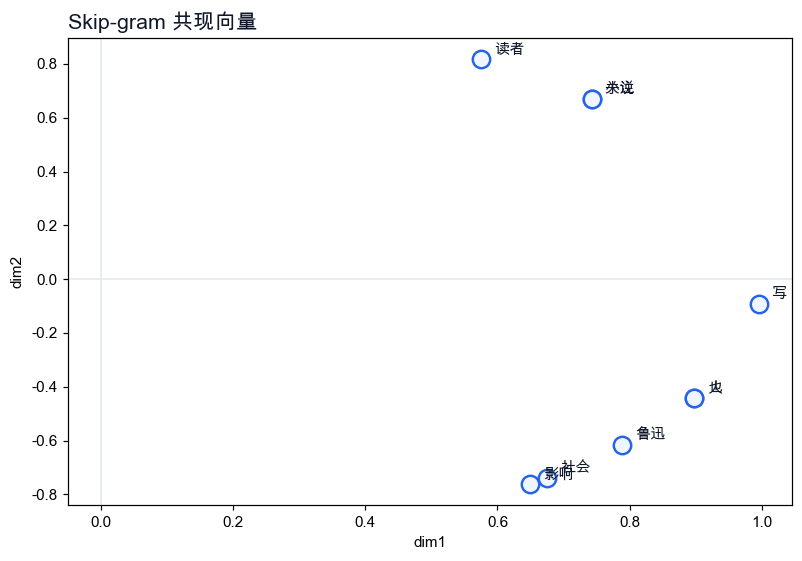

In [4]:
# 绘制词向量位置。
fig, ax = plt.subplots(figsize=(7.4, 5.2))
ax.scatter(emb[:, 0], emb[:, 1], s=130, color="#eff6ff", edgecolor="#2563eb", linewidth=1.6)
for word, i in word_to_id.items():
    ax.text(emb[i, 0] + 0.02, emb[i, 1] + 0.02, word, color="#0f172a")
ax.axhline(0, color="#e2e8f0", linewidth=1)
ax.axvline(0, color="#e2e8f0", linewidth=1)
ax.set_title("Skip-gram 共现向量", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("dim1")
ax.set_ylabel("dim2")
plt.tight_layout()
plt.show()